<a href="https://colab.research.google.com/github/iishikawalia/Machine-Learning/blob/main/StockMarketDataAnalysisProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas, matplotlib, yfinance

In [2]:
data = yfinance.download("AAPL", start="2023-01-01", end="2023-12-31")

/tmp/ipykernel_36286/2125064623.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yfinance.download("AAPL", start="2023-01-01", end="2023-12-31")
[*********************100%***********************]  1 of 1 completed


In [3]:
print(data.head(5))

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2023-01-03  123.096031  128.834011  122.210234  128.223801  112117500
2023-01-04  124.365654  126.629356  123.105858  124.887288   89113600
2023-01-05  123.046814  125.753411  122.790923  125.123513   80962700
2023-01-06  127.574165  128.233589  122.918825  124.021150   87754700
2023-01-09  128.095825  131.304382  127.839934  128.410782   70790800


In [4]:
print(type(data))

<class 'pandas.core.frame.DataFrame'>


In [5]:
df=data

In [6]:
df.isnull()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2023-01-03,False,False,False,False,False
2023-01-04,False,False,False,False,False
2023-01-05,False,False,False,False,False
2023-01-06,False,False,False,False,False
2023-01-09,False,False,False,False,False
...,...,...,...,...,...
2023-12-22,False,False,False,False,False
2023-12-26,False,False,False,False,False


In [7]:
len(df.isnull())

250

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 250 entries, 2023-01-03 to 2023-12-29
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   250 non-null    float64
 1   (High, AAPL)    250 non-null    float64
 2   (Low, AAPL)     250 non-null    float64
 3   (Open, AAPL)    250 non-null    float64
 4   (Volume, AAPL)  250 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.7 KB


In [9]:
df.columns

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])

In [10]:
df.columns = [col[0] for col in df.columns]

In [11]:
df.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [12]:
df.index.is_monotonic_increasing

True

In [13]:
df['MA20'] = df['Close'].rolling(20).mean()

In [14]:
df['MA50'] = df['Close'].rolling(50).mean()

In [15]:
df['MA20'].head(25)

,MA20
Date,
2023-01-03,NaN
2023-01-04,NaN
2023-01-05,NaN
2023-01-06,NaN
2023-01-09,NaN
2023-01-10,NaN
2023-01-11,NaN
2023-01-12,NaN
2023-01-13,NaN


In [16]:
df[['Close','MA20']].tail(25)

,Close,MA20
Date,,
2023-11-24,188.016800,180.669082
2023-11-27,187.838623,181.747444
2023-11-28,188.442352,182.753692
2023-11-29,187.422958,183.685249
2023-11-30,187.996979,184.487361
2023-12-01,189.273727,185.175395
2023-12-04,187.482330,185.819327
2023-12-05,191.431320,186.533202
2023-12-06,190.342621,187.064643


In [17]:
(df['MA20'] - df['Close'].rolling(20).mean()).abs().max()

0.0

In [18]:
(df['MA50'] - df['Close'].rolling(50).mean()).abs().max()

0.0

In [19]:
df['MA10'] = df['Close'].rolling(10).mean()

In [20]:
df['SIGNAL']='BUY' if 'MA10'>'MA50' else 'SELL'

In [21]:
df[['MA10','MA50']].tail(20)

,MA10,MA50
Date,,
2023-12-01,188.423563,177.446822
2023-12-04,188.397826,177.741165
2023-12-05,188.592801,178.088985
2023-12-06,188.759073,178.496476
2023-12-07,189.052031,178.972813
2023-12-08,189.620128,179.472514
2023-12-11,189.955644,179.911855
2023-12-12,190.382216,180.331270
2023-12-13,191.232382,180.841704


In [22]:
df[['MA10','MA50']].head(100)

,MA10,MA50
Date,,
2023-01-03,NaN,NaN
2023-01-04,NaN,NaN
2023-01-05,NaN,NaN
2023-01-06,NaN,NaN
2023-01-09,NaN,NaN
...,...,...
2023-05-19,170.887138,162.199947
2023-05-22,170.979893,162.711357
2023-05-23,170.982584,163.131812


In [23]:
df = df.dropna()

In [24]:
df = df.drop(columns=['MA10', 'MA20','MA50'])

In [25]:
df['MA10'] = df['Close'].rolling(10).mean()

In [26]:
df['MA20'] = df['Close'].rolling(20).mean()

In [27]:
df['MA50'] = df['Close'].rolling(50).mean()

In [28]:
(df['MA10'] - df['Close'].rolling(10).mean()).abs().max()

0.0

In [29]:
(df['MA20'] - df['Close'].rolling(20).mean()).abs().max()

0.0

In [30]:
(df['MA50'] - df['Close'].rolling(50).mean()).abs().max()

0.0

In [31]:
df=df.drop(columns=['SIGNAL'])

In [32]:
df['SIGNAL'] = (df['MA10'] > df['MA50']).map({True: 'BUY', False: 'SELL'})

In [33]:
df['SIGNAL'].value_counts()

,count
SIGNAL,
SELL,110
BUY,91


In [34]:
(df['SIGNAL'] != df['SIGNAL'].shift(1)).sum()

np.int64(6)

In [35]:
if (df['SIGNAL'] != df['SIGNAL'].shift(1)).any():
    print("Signal changes exist")
    print(df[df['SIGNAL'] != df['SIGNAL'].shift(1)])

Signal changes exist
                 Close        High         Low        Open    Volume  \
Date                                                                   
2023-03-15  150.805252  151.061534  147.779086  149.030954  77167900   
2023-05-24  169.620361  170.192871  168.317419  168.880049  45143500   
2023-08-10  175.671188  178.415278  175.305972  177.161678  54686900   
2023-10-17  175.097916  176.353208  172.775147  174.603708  57549400   
2023-10-23  170.995987  171.994282  167.961542  168.930201  55980100   
2023-11-10  184.483475  184.651740  181.642988  182.078467  66133400   

                  MA10        MA20        MA50 SIGNAL  
Date                                                   
2023-03-15         NaN         NaN         NaN   SELL  
2023-05-24  170.836469  169.296082  163.515999    BUY  
2023-08-10  184.430579  187.600593  185.010784   SELL  
2023-10-17  175.806616  173.437377  175.718189    BUY  
2023-10-23  175.028737  173.283682  175.404916   SELL  
2023-11-10

In [36]:
df['Uptrend_3days'] = False
count=0
for i in range(2, len(df)):
    if df['SIGNAL'].iloc[i] == df['SIGNAL'].iloc[i-1] == df['SIGNAL'].iloc[i-2]:
        print("3 days consecutive same signal at index", i, "on date: ", df.index[i].date())
        count+=1
        df.loc[df.index[i], 'Uptrend_3days'] = True
print("total no. of times: ", count)


3 days consecutive same signal at index 2 on date:  2023-03-17
3 days consecutive same signal at index 3 on date:  2023-03-20
3 days consecutive same signal at index 4 on date:  2023-03-21
3 days consecutive same signal at index 5 on date:  2023-03-22
3 days consecutive same signal at index 6 on date:  2023-03-23
3 days consecutive same signal at index 7 on date:  2023-03-24
3 days consecutive same signal at index 8 on date:  2023-03-27
3 days consecutive same signal at index 9 on date:  2023-03-28
3 days consecutive same signal at index 10 on date:  2023-03-29
3 days consecutive same signal at index 11 on date:  2023-03-30
3 days consecutive same signal at index 12 on date:  2023-03-31
3 days consecutive same signal at index 13 on date:  2023-04-03
3 days consecutive same signal at index 14 on date:  2023-04-04
3 days consecutive same signal at index 15 on date:  2023-04-05
3 days consecutive same signal at index 16 on date:  2023-04-06
3 days consecutive same signal at index 17 on da

In [37]:
init_amt=10000
cash=init_amt
holding=False
quantity=0
buy_price=0
buy_date=None
sell_price=0
sell_date=None
profit=0
trades=[]
equity = []

In [38]:
df = df.dropna(subset=['MA10', 'MA50'])

In [39]:
for i in range(len(df)-1):

  signal = df['SIGNAL'].iloc[i]
  next_open = df['Open'].iloc[i + 1]
  price = df['Close'].iloc[i]
  date = df.index[i]

  if signal == 'BUY' and not holding:
    quantity = int(cash / next_open)
    if quantity > 0:
      buy_price = next_open
      buy_date = date
      cash -= quantity * buy_price
      holding = True
  elif signal == 'SELL' and holding:
    sell_price = next_open
    sell_date = date
    cash += quantity * sell_price
    holding = False
    profit = (sell_price - buy_price) * quantity
    trades.append({
        'Buy Date': buy_date,
        'Sell Date': sell_date,
        'Buy Price': buy_price,
        'Sell Price': sell_price,
        'Quantity': quantity,
        'Profit': profit
        })
  if holding:
    current_value = quantity * price
    equity.append({
        'Amt':cash+current_value,
        'Date':date})
  else:
    equity.append({
        'Amt':cash,
        'Date':date})

# closing...
if holding:
  sell_price = df['Close'].iloc[-1]
  sell_date = df.index[-1]
  cash += quantity * sell_price
  profit = (sell_price - buy_price) * quantity
  trades.append({
      'Buy Date': buy_date,
      'Sell Date': sell_date,
      'Buy Price': buy_price,
      'Sell Price': sell_price,
      'Quantity': quantity,
      'Profit': profit
      })

In [40]:
total_profit = cash - init_amt
print("Final Cash:", cash)
print("Total Profit:", total_profit)
print("Number of Trades:", len(trades))

for t in trades:
    print(t)

Final Cash: 10512.523847228445
Total Profit: 512.5238472284454
Number of Trades: 3
{'Buy Date': Timestamp('2023-05-24 00:00:00'), 'Sell Date': Timestamp('2023-08-10 00:00:00'), 'Buy Price': np.float64(170.1830440486123), 'Sell Price': np.float64(175.26597277471524), 'Quantity': 58, 'Profit': np.float64(294.80986611397105)}
{'Buy Date': Timestamp('2023-10-17 00:00:00'), 'Sell Date': Timestamp('2023-10-23 00:00:00'), 'Buy Price': np.float64(173.54610256783715), 'Sell Price': np.float64(171.045411263789), 'Quantity': 59, 'Profit': np.float64(-147.54078693884148)}
{'Buy Date': Timestamp('2023-11-10 00:00:00'), 'Sell Date': Timestamp('2023-12-29 00:00:00'), 'Buy Price': np.float64(183.9094650326421), 'Sell Price': np.float64(190.5504608154297), 'Quantity': 55, 'Profit': np.float64(365.2547680533179)}


In [41]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

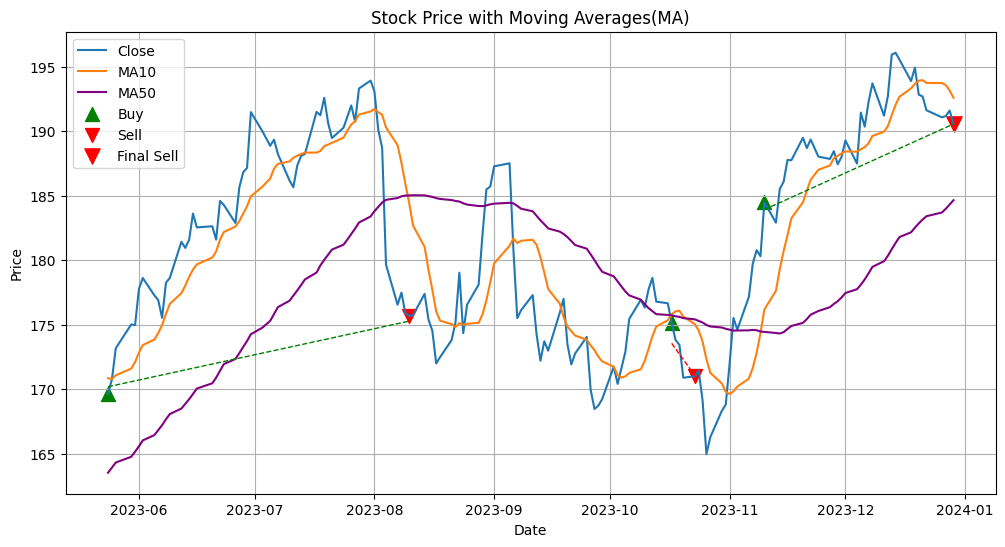

In [42]:
buy_points = df[(df['SIGNAL'] == 'BUY') & (df['SIGNAL'].shift(1) != 'BUY')]
sell_points = df[(df['SIGNAL'] == 'SELL') & (df['SIGNAL'].shift(1) != 'SELL')]

plt.figure(figsize=(12,6))

plt.plot(df.index, df['Close'], label='Close')
plt.plot(df.index, df['MA10'], label='MA10')
plt.plot(df.index, df['MA50'], label='MA50', c='Purple')

plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Stock Price with Moving Averages(MA)")

plt.scatter(buy_points.index, buy_points['Close'], marker='^', color='green', label='Buy', s=100)
plt.scatter(sell_points.index, sell_points['Close'], marker='v', color='red', label='Sell', s=100)
last_trade = trades[-1]
plt.scatter(last_trade['Sell Date'], last_trade['Sell Price'], color='red', marker='v', s=120, label='Final Sell')

for trade in trades:
    color = 'green' if trade['Profit'] > 0 else 'red'
    plt.plot(
        [trade['Buy Date'], trade['Sell Date']],   # x-axis
        [trade['Buy Price'], trade['Sell Price']], # y-axis
        color=color, linestyle='--', linewidth=1
    )

plt.legend()
plt.grid()


In [43]:
profits = [t['Profit'] for t in trades]

total_profit = sum(profits)
avg_profit = total_profit / len(profits)

print("Total Profit:", total_profit)
print("Average Profit per Trade:", avg_profit)

Total Profit: 512.5238472284475
Average Profit per Trade: 170.8412824094825


In [44]:
gains = len([p for p in profits if p > 0])
losses = len([p for p in profits if p < 0])

print("Gains:", gains)
print("Losses:", losses)

Gains: 2
Losses: 1


In [45]:
print("Number of Trades:", len(trades))

Number of Trades: 3


In [46]:
profitable_trades = [t for t in trades if t['Profit'] > 0]
print("Profitable Trades:", len(profitable_trades)/len(trades),"%")

Profitable Trades: 0.6666666666666666 %


In [47]:
durations = [(t['Sell Date'] - t['Buy Date']).days for t in trades]
print("Average Holding Days:", sum(durations)/len(durations))

Average Holding Days: 44.333333333333336


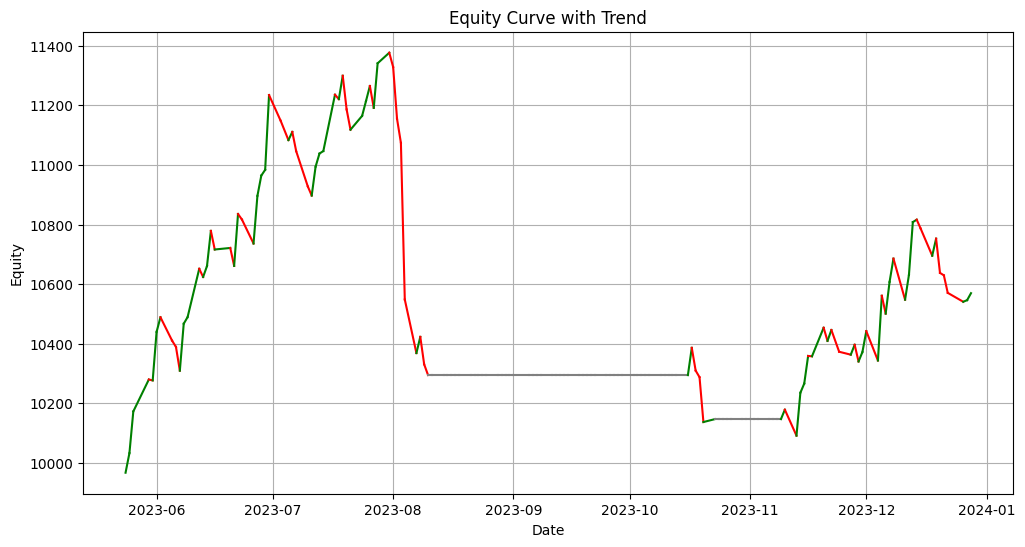

In [48]:
amounts = [e['Amt'] for e in equity]
dates = [e['Date'] for e in equity]

plt.figure(figsize=(12,6))

for i in range(1, len(amounts)):
    if amounts[i] > amounts[i-1]:
        color = 'green'
    elif amounts[i] < amounts[i-1]:
        color = 'red'
    else:
        color = 'gray'

    plt.plot(dates[i-1:i+1], amounts[i-1:i+1], color=color)

plt.xlabel("Date")
plt.ylabel("Equity")
plt.title("Equity Curve with Trend")
plt.grid()

plt.show()
